<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/main/benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tester for Density Peak Algorithm

Distanza di cut-off (dc) calcolata: 0.2919


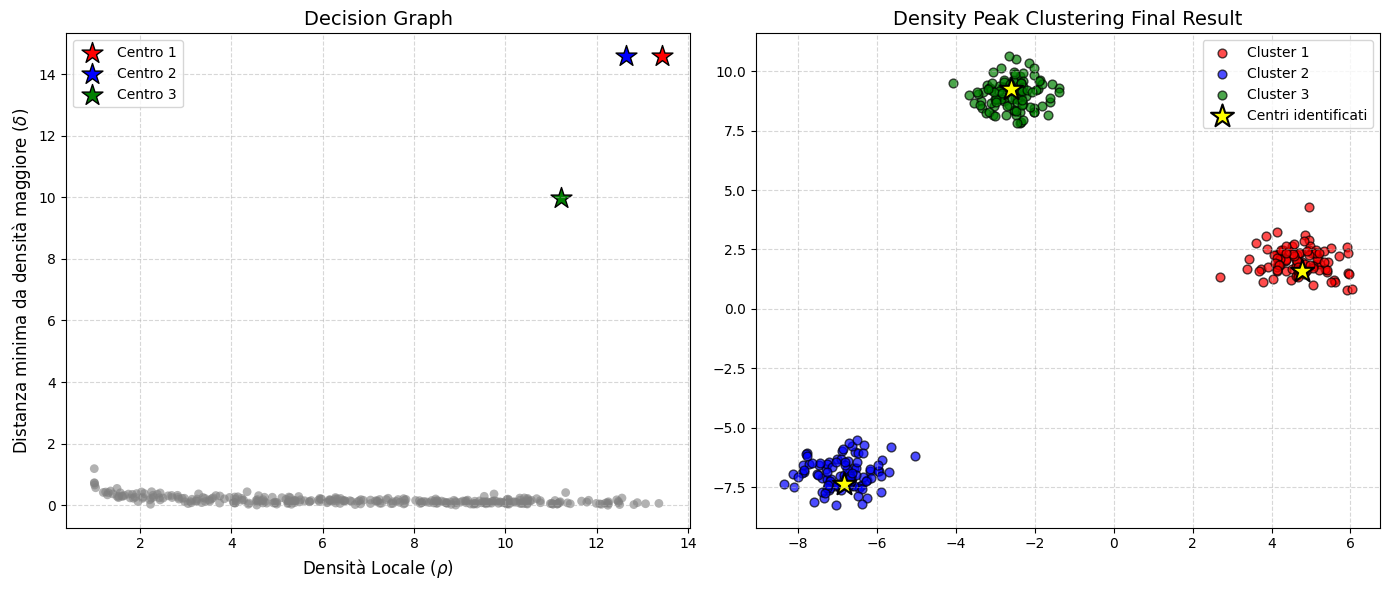

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 1. Generazione di dati di esempio (3 cluster ben separati)
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)
n_samples = X.shape[0]

# 2. Calcolo della matrice delle distanze euclidee
dist_matrix = np.sqrt(np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=-1))

# 3. Scelta del cut-off distance (dc)
# Una regola comune è scegliere dc in modo che il numero medio di vicini sia circa l'1-2% del totale dei punti
percent = 2.0
position = int((n_samples * (n_samples - 1) / 2) * percent / 100)
tri_upper = dist_matrix[np.triu_indices(n_samples, k=1)]
dc = np.sort(tri_upper)[position]

print(f"Distanza di cut-off (dc) calcolata: {dc:.4f}")

# 4. Calcolo della densità locale (rho) usando un kernel gaussiano
rho = np.zeros(n_samples)
for i in range(n_samples):
    # Kernel gaussiano continuo per stabilità
    rho[i] = np.sum(np.exp(-(dist_matrix[i, :] / dc) ** 2))

# 5. Calcolo di delta (distanza minima dal punto più denso più vicino)
delta = np.zeros(n_samples)
nearest_higher_density = -np.ones(n_samples, dtype=int)

# Ordiniamo i punti per densità decrescente
sorted_indices = np.argsort(-rho)

for i in range(1, n_samples):
    curr_idx = sorted_indices[i]
    # Consideriamo solo i punti con densità strettamente maggiore
    larger_density_indices = sorted_indices[:i]

    # Troviamo la distanza minima e l'indice del punto più denso più vicino
    distances = dist_matrix[curr_idx, larger_density_indices]
    min_dist_idx = np.argmin(distances)

    delta[curr_idx] = distances[min_dist_idx]
    nearest_higher_density[curr_idx] = larger_density_indices[min_dist_idx]

# Per il punto a densità massima globale, assegniamo il valore massimo di delta riscontrato
global_max_density_idx = sorted_indices[0]
delta[global_max_density_idx] = np.max(delta)

# 6. Identificazione dei centri (decisione manuale basata su una soglia combinata gamma = rho * delta)
gamma = rho * delta
n_clusters = 3
centers = np.argsort(-gamma)[:n_clusters]

# 7. Assegnazione dei punti non-centro ai rispettivi cluster
cluster_assignment = -np.ones(n_samples, dtype=int)
for i, center_idx in enumerate(centers):
    cluster_assignment[center_idx] = i

# I punti vengono assegnati nello stesso ordine di densità decrescente
for i in range(n_samples):
    curr_idx = sorted_indices[i]
    if cluster_assignment[curr_idx] == -1:  # Se non è un centro
        # Prende l'etichetta del suo vicino più denso più vicino
        parent = nearest_higher_density[curr_idx]
        cluster_assignment[curr_idx] = cluster_assignment[parent]

# 8. Plot dei Risultati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: Decision Graph (rho vs delta)
ax1.scatter(rho, delta, c='gray', alpha=0.6, edgecolors='none', s=40)
# Evidenziamo i centri identificati
colors = ['red', 'blue', 'green']
for i, center_idx in enumerate(centers):
    ax1.scatter(rho[center_idx], delta[center_idx], c=colors[i], marker='*', s=250, edgecolors='black', label=f'Centro {i+1}')
ax1.set_xlabel(r'Densità Locale ($\rho$)', fontsize=12)
ax1.set_ylabel(r'Distanza minima da densità maggiore ($\delta$)', fontsize=12)
ax1.set_title('Decision Graph', fontsize=14)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Grafico 2: Risultato del Clustering
for i in range(n_clusters):
    cluster_points = X[cluster_assignment == i]
    ax2.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], label=f'Cluster {i+1}', alpha=0.7, edgecolors='k', s=40)
# Disegniamo i centri sul plot spaziale
ax2.scatter(X[centers, 0], X[centers, 1], c='yellow', marker='*', s=300, edgecolors='black', linewidths=1.5, label='Centri identificati')
ax2.set_title('Density Peak Clustering Final Result', fontsize=14)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()